In [4]:
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np
import fsspec
import xarray as xr

np.random.seed(420)

In [7]:
VEG_CLASSES = [10,20,30,40,60,90,95,100]
s2_vars = ["kNDVI", "CIRE", "IRECI", "NDWI", "NDMI", "NIRv"]   #  UPDATE!!
s1_vars = ["vv", "vh"]
era5_vars = [
    "pei_30_mean", "pei_90_mean", "pei_180_mean", "pei_360_mean",   # UPDATE!
    "t2m_mean", "t2mmax_mean", "t2mmin_mean", 
    "tp_dailymax_mean", "tp_dailymean_mean", "tp_rollingmax_mean"
]
static_vars = ["COP_DEM", "is_veg"]

In [8]:
cube_id = "2016-0237-IND_postprocessed.zarr"
url = "/scratch/sloeblein/postprocessed/" + cube_id 
ds = xr.open_zarr(url)

In [9]:
import torch.nn.functional as F
from model.dataset import encode_landcover

# 1. Extract ESA_LC and convert to torch
lc = torch.from_numpy(ds["ESA_LC"].values).long() # (T, H, W)
print(lc.shape)

# Define existing class labels (plus "0" for possible NaNs)
labels = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 95, 100]
num_classes = len(labels) 

# 3. Create Mapping-Matrix (Mapping of 0-100 (labels) to index 0 - 11)
mapping = torch.zeros(101, dtype=torch.long)
for i, val in enumerate(labels):
    mapping[val] = i

# 4. Apply mapping
lc_mapped = mapping[lc]

# 5. One-Hot Encoding
lc_onehot = F.one_hot(lc_mapped, num_classes=num_classes) # (T, H, W, 12 (classes))
lc_onehot = lc_onehot.permute(0, 3, 1, 2).float() # (T, 12, H, W)
print(lc_onehot.shape)

torch.Size([123, 1000, 1000])
torch.Size([123, 12, 1000, 1000])


In [10]:
lc_onehot_alternate = encode_landcover(lc)
print(lc_onehot_alternate.shape)

torch.Size([123, 12, 1000, 1000])


In [11]:
x_stat_raw = torch.from_numpy(ds[static_vars].to_array().values).float() # (C_stat, T, H, W)
print(x_stat_raw.shape)
x_static = torch.cat([lc_onehot, x_stat_raw.permute(1, 0, 2, 3)], dim=1).permute(1, 0, 2, 3) # (13, T, H, W)
print(x_static.shape)

torch.Size([2, 123, 1000, 1000])
torch.Size([14, 123, 1000, 1000])


In [12]:
x_s2 = torch.from_numpy(ds[s2_vars].to_array().values).float()      # (C_s2, T, H, W)
x_s1 = torch.from_numpy(ds[s1_vars].to_array().values).float()      # (C_s1, T, H, W)
x_era5_1d = torch.from_numpy(ds[era5_vars].to_array().values).float() 

x_context = torch.cat([x_s2, x_s1,x_static], dim=0).permute(1, 0, 2, 3)   # (T_ctx, C_all, H, W)

In [13]:
lc = torch.from_numpy(ds["ESA_LC"].values).long() # (T, H, W)
lc_onehot = encode_landcover(lc)

In [14]:
lc_onehot.shape

torch.Size([123, 12, 1000, 1000])

In [15]:
patch_size = 256
dim_max = 1000
tiled_list = []
    
# 1. Calculate how many patches we need to cover the dimension
# We use ceil to ensure we cover the full 1000px
num_tiles = int(np.ceil(dim_max / patch_size))
print(num_tiles)

# 2. Calculate the optimal stride
if num_tiles > 1:
    stride = (dim_max - patch_size) // (num_tiles - 1)
    print(stride)
else:
    stride = 0

offsets = [i * stride for i in range(num_tiles)]
print(offsets)
# 4. Final safety check: ensure the last patch ends exactly at dim_max
if offsets[-1] + patch_size != dim_max:
    print("no")
    offsets[-1] = dim_max - patch_size

4
248
[0, 248, 496, 744]


In [16]:
248 + 248 + 248 + 256

1000

In [ ]:
from dataset import ARCEME_Dataset, get_llto_splits_strict, get_llto_splits, get_val_tiles_auto


# --- 1. Splits generieren ---
# Nutze deine LLTO Funktion von oben
folds = get_llto_splits_strict(root_dir="/scratch/sloeblein/postprocessed",csv_path="../data_processing/data/train_test_split.csv", k=3)

# Wir nehmen beispielhaft den ersten Fold
train_paths, val_paths = folds[0]

val_tiles = get_val_tiles_auto(val_paths, patch_size=256)

# --- 2. Datasets instanziieren ---
train_dataset = ARCEME_Dataset(train_paths, 
                               context_length = 20, 
                               target_length = 5,
                               patch_size=256,  
                               train=True,
                               s2_vars=s2_vars,
                               s1_vars=s1_vars,
                               era5_vars=era5_vars,
                               static_vars=static_vars)
val_dataset = ARCEME_Dataset(val_paths,
                             context_length = 20, 
                             target_length = 5, 
                             patch_size=256, 
                             train=False,
                             s2_vars=s2_vars,
                             s1_vars=s1_vars,
                             era5_vars=era5_vars,
                             static_vars=static_vars,
                             fixed_tiles=val_tiles) # False = Center Crop für Vergleichbarkeit

# --- 3. DataLoader erstellen ---
batch_size = 4 

train_loader = DataLoader(
    train_dataset, 
    batch_size=batch_size, 
    shuffle=True, 
    num_workers=4,   # Lädt 4 Patches parallel
    pin_memory=True  # Beschleunigt Transfer zur GPU
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=batch_size, 
    shuffle=False, 
    num_workers=2,
    pin_memory=True
)

# --- 4. Test-Lauf: Wie kommen die Daten an? ---
if __name__ == "__main__":
    x_ctx, x_fut, y, mask, meta, baseline = next(iter(train_loader))
    
    print(f"Input Context Shape: {x_ctx.shape}")  # [Batch, Time, Channels(23), 128, 128]
    print(f"Future Weather Shape: {x_fut.shape}") # [Batch, Time, Channels(10), 128, 128]
    print(f"Target kNDVI Shape: {y.shape}")       # [Batch, Time, 1, 128, 128]
    print(f"Loss Mask Shape: {mask.shape}")       # [Batch, Time, 1, 128, 128]
    print(f"Meta Shape: {meta.shape}")  
    print(f"Baseline Shape: {baseline.shape}")  

--- LLTO-CV Initialization (Total Cubes: 13) ---
Fold 0:
  > Training:     6 cubes ( 46.2%)
  > Validation:   2 cubes ( 15.4%)
  > Excluded:     5 cubes ( 38.5%) [Blocked due to Loc/Time overlap]
Fold 1:
  > Training:     8 cubes ( 61.5%)
  > Validation:   2 cubes ( 15.4%)
  > Excluded:     3 cubes ( 23.1%) [Blocked due to Loc/Time overlap]
Fold 2:
  > Training:     8 cubes ( 61.5%)
  > Validation:   2 cubes ( 15.4%)
  > Excluded:     3 cubes ( 23.1%) [Blocked due to Loc/Time overlap]
Validation Strategy: Created 16 tiles per cube.
Grid: 4x4 patches, Stride: 248, Total Tiles: 32


In [ ]:
folds[0]

(['/scratch/sloeblein/postprocessed/2016-0237-IND_postprocessed.zarr',
  '/scratch/sloeblein/postprocessed/2019-0413-ESP_postprocessed.zarr',
  '/scratch/sloeblein/postprocessed/2020-0489-ZAF_postprocessed.zarr',
  '/scratch/sloeblein/postprocessed/2021-0140-ARG_postprocessed.zarr',
  '/scratch/sloeblein/postprocessed/2021-0227-KEN_postprocessed.zarr'],
 ['/scratch/sloeblein/postprocessed/2018-0376-PRT_postprocessed.zarr',
  '/scratch/sloeblein/postprocessed/2021-0561-ESP_postprocessed.zarr'])

In [ ]:
n_patches = 20
patch_size = 128
coords = []
###################################

lc = ds.ESA_LC.isel(time_esa_worldcover=0).values 
        
# 1. Welche Klassen sind da und wie viele Pixel haben sie?
present_classes, counts = np.unique(lc, return_counts=True)

# Filtere nur die Klassen, die in deiner VEG_CLASSES Liste sind
veg_mask = np.isin(present_classes, [10, 20, 30, 40, 60, 90, 95, 100])
present_classes = present_classes[veg_mask]
counts = counts[veg_mask]

n_classes = len(present_classes)
patches_per_class = {c: 1 for c in present_classes} # Minimum 1

remaining_slots = n_patches - n_classes
if remaining_slots > 0:
    # Proportionale Verteilung der restlichen Slots basierend auf Pixel-Anzahl
    proportions = counts / counts.sum()
    extra_slots = np.round(proportions * remaining_slots).astype(int)
    for i, c in enumerate(present_classes):
        patches_per_class[c] += extra_slots[i]

for c_class, target_count in patches_per_class.items():
            y_indices, x_indices = np.where(lc == c_class)
            sampled_for_this_class = 0
            attempts = 0
            
            # Mische die Indizes zufällig
            idx_pool = np.arange(len(y_indices))
            np.random.shuffle(idx_pool)
            
            while sampled_for_this_class < target_count and attempts < len(idx_pool):
                idx = idx_pool[attempts]
                attempts += 1
                
                y_center, x_center = y_indices[idx], x_indices[idx]

                def is_overlapping(new_y, new_x, existing_coords, patch_size, threshold=0.2):
                    for ey, ex in existing_coords:
                        # Berechne die Schnittmenge (Intersection)
                        y_inter = max(0, min(new_y + patch_size, ey + patch_size) - max(new_y, ey))
                        x_inter = max(0, min(new_x + patch_size, ex + patch_size) - max(new_x, ex))
                        intersection_area = y_inter * x_inter
                        
                        # Falls die Überlappung größer als X% der Patch-Fläche ist
                        if intersection_area > (patch_size**2 * threshold):
                            return True
                    return False

                
                # Berechne Startpunkt (Padding beachten, damit Patch im 1000x1000 Feld bleibt)
                y_start = int(np.clip(y_center - patch_size // 2, 0, lc.shape[0] - patch_size))
                x_start = int(np.clip(x_center - patch_size // 2, 0, lc.shape[1] - patch_size))

                if not is_overlapping(y_start, x_start, coords, patch_size, threshold=0.05):
                    coords.append((y_start, x_start))
                    sampled_for_this_class += 1
                
                # if (y_start, x_start) not in coords:
                #     coords.append((y_start, x_start))
                #     sampled_for_this_class += 1
                
                if len(coords) >= n_patches:
                    break

In [ ]:
# 1. Sum up the mask pixels for each time step
# This gives you a 1D array across the time dimension
mask_sums = ds.s2_final_mask.sum(dim=['x', 'y'])

# 2. Find the index of the minimum sum
best_time_idx = mask_sums.argmax(dim='time_sentinel_2_l2a').values

# 3. Retrieve the actual timestamp or the data at that index
best_timestamp = ds.time_sentinel_2_l2a.values[best_time_idx]
best_data = ds.isel(time_sentinel_2_l2a=best_time_idx)

print(f"Best index: {best_time_idx}")
print(f"Date with minimal mask: {best_timestamp}")

Best index: 77
Date with minimal mask: 2020-06-11T00:00:00.000000000


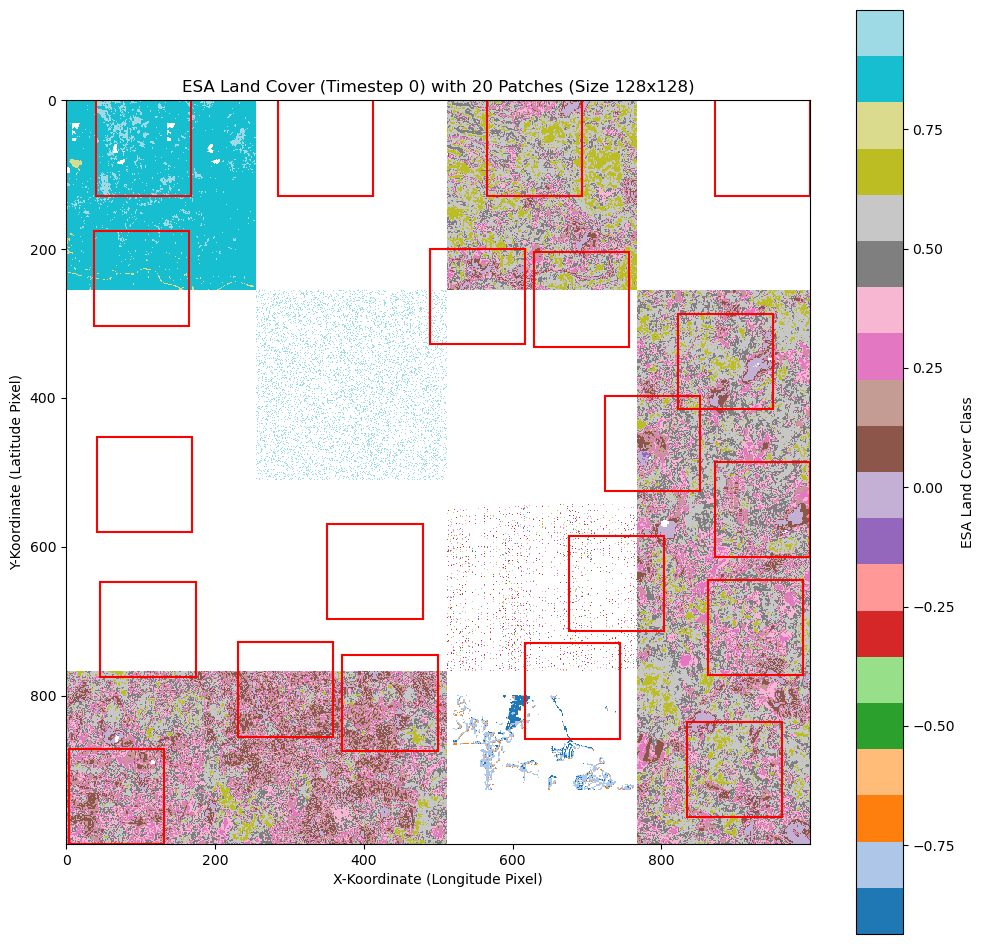

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

def plot_lc_with_patches(ds, coords, patch_size):
    """
    Plots the ESA_LC layer at timestep 0 for a given cube and overlays the specified patches.

    Args:
        ds (xarray.Dataset): The xarray Dataset containing the 'ESA_LC' variable.
        coords (list): A list of (y_start, x_start) tuples representing the top-left
                       corner of each patch.
        patch_size (int): The size of the square patches (e.g., 128).
    """
    # 1. Den Landcover-Layer für den ersten Timestep extrahieren
    lc_map = ds.ESA_LC.isel(time_esa_worldcover=0).values

    lc_map = ds.NDVI_basic.isel(time_sentinel_2_l2a=77).values

    # 2. Eine neue Figure und Axes erstellen
    fig, ax = plt.subplots(1, 1, figsize=(12, 12))

    # 3. Den Landcover-Layer als Bild plotten
    # cmap='tab20' ist gut für diskrete Klassen
    # origin='upper' ist Standard für Bilddaten (0,0 oben links)
    im = ax.imshow(lc_map, cmap='tab20', interpolation='nearest', origin='upper')

    # 4. Eine Colorbar hinzufügen, um die LC-Klassen zu visualisieren
    # Hier müssten deine LC-Klassennamen und -werte hinterlegt werden
    # lc_class_names = {10: "Trees", 20: "Shrubs", ...}
    # cbar = fig.colorbar(im, ax=ax, ticks=list(lc_class_names.keys()), orientation='vertical')
    # cbar.ax.set_yticklabels(list(lc_class_names.values()))
    
    # Für diesen Plot lassen wir die Labels generisch oder du fügst sie manuell ein
    fig.colorbar(im, ax=ax, orientation='vertical', label='ESA Land Cover Class')


    # 5. Die Patches als Rechtecke darüber zeichnen
    for y_start, x_start in coords:
        # Erstelle ein Rechteck (Rect) Objekt
        rect = patches.Rectangle(
            (x_start, y_start),  # (x, y) der unteren linken Ecke (Achtung: Matplotlib hat oft y unten)
            patch_size,          # Breite
            patch_size,          # Höhe
            linewidth=1.5,       # Linienbreite
            edgecolor='red',     # Rote Umrandung
            facecolor='none'     # Keine Füllung
        )
        # Füge das Rechteck zur Achse hinzu
        ax.add_patch(rect)

    ax.set_title(f"ESA Land Cover (Timestep 0) with {len(coords)} Patches (Size {patch_size}x{patch_size})")
    ax.set_xlabel("X-Koordinate (Longitude Pixel)")
    ax.set_ylabel("Y-Koordinate (Latitude Pixel)")
    plt.show()

# --- Beispiel-Nutzung (angenommen, 'ds' und 'coords' sind bereits definiert) ---
# ds ist dein geladenes xarray.Dataset für einen einzelnen Cube
# coords ist deine Liste der Patch-Startkoordinaten
# patch_size ist die Größe deiner Patches, z.B. 128

plot_lc_with_patches(ds, coords, patch_size=256)

In [68]:
np.unique(test)

array([0, 1], dtype=uint8)

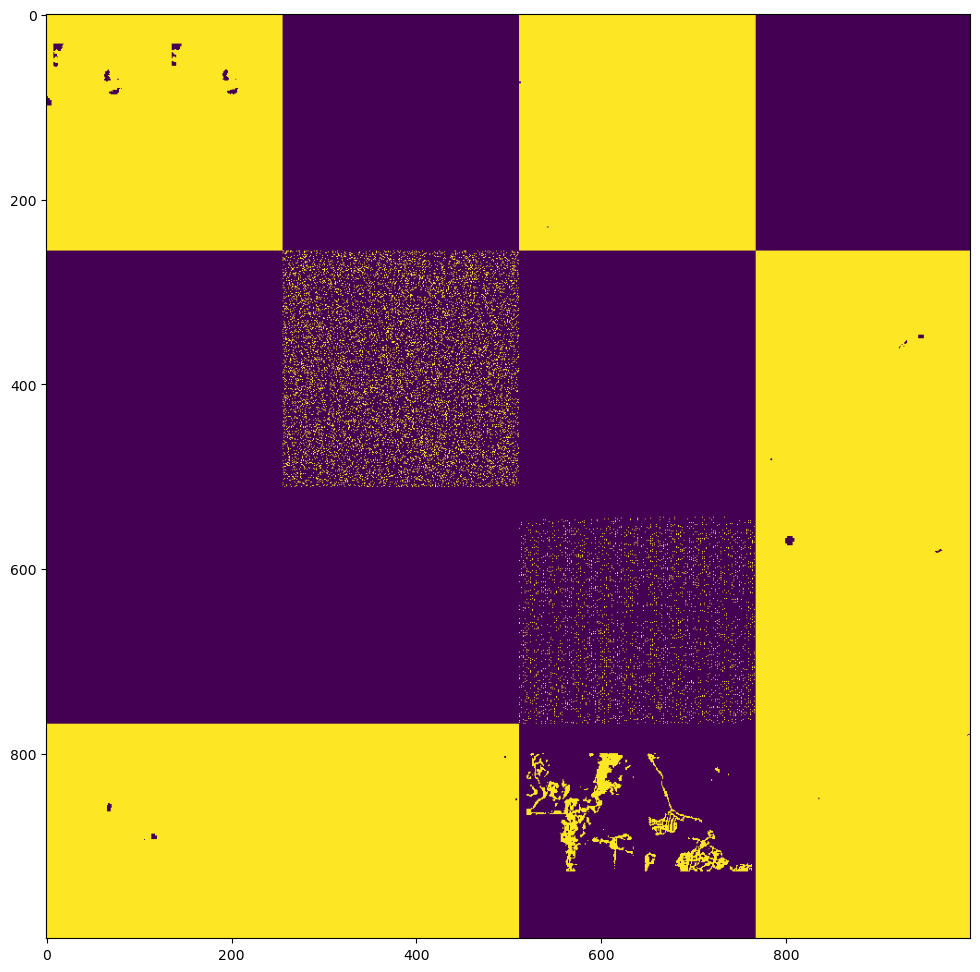

In [76]:
test = ds.s2_final_mask.isel(time_sentinel_2_l2a=77).values

fig, ax = plt.subplots(1, 1, figsize=(12, 12))

# 3. Den Landcover-Layer als Bild plotten
# cmap='tab20' ist gut für diskrete Klassen
# origin='upper' ist Standard für Bilddaten (0,0 oben links)
im = ax.imshow(test)
plt.show()

In [ ]:
import torch
from torch.utils.data import Dataset
import xarray as xr
import numpy as np
import random

class SingleCubeDataset(Dataset):
    def __init__(self, cube_path, features, target_var="NDVI_strict", 
                 patch_size=128, n_patches=20, context_steps=70, pred_steps=5):
        """
        Args:
            cube_path: Pfad zur .zarr Datei
            features: Liste der 38 Variablen-Namen, die als Input dienen
            target_var: Die Variable, die vorhergesagt werden soll (z.B. NDVI)
            patch_size: Größe der Quadrate (128)
            n_patches: Anzahl der gewünschten Patches (20)
            context_steps: Input-Zeitfenster (70)
            pred_steps: Vorhersage-Zeitfenster (5)
        """
        self.ds = xr.open_dataset(cube_path)
        self.features = features
        self.target_var = target_var
        self.patch_size = patch_size
        self.context_steps = context_steps
        self.pred_steps = pred_steps
        
        # 1. Patch-Koordinaten generieren (Smart Selection)
        self.patch_coords = self._generate_stratified_patches(n_patches)

    def _generate_stratified_patches(self, n_patches):
        coords = []
        # Lade die Landcover-Daten einmal in den RAM für schnellen Zugriff
        lc = self.ds.ESA_LC.isel(time_esa_worldcover=0).values 
        
        # 1. Welche Klassen sind da und wie viele Pixel haben sie?
        present_classes, counts = np.unique(lc, return_counts=True)
        
        # Filtere nur die Klassen, die in deiner VEG_CLASSES Liste sind
        veg_mask = np.isin(present_classes, [10, 20, 30, 40, 60, 90, 95, 100])
        present_classes = present_classes[veg_mask]
        counts = counts[veg_mask]
        
        if len(present_classes) == 0:
            raise ValueError("Keine der definierten VEG_CLASSES im Cube gefunden!")
    
        # 2. Berechne die Ziel-Anzahl pro Klasse
        # Regel: Jede vorhandene Klasse bekommt mind. 1 Patch, der Rest wird proportional verteilt
        n_classes = len(present_classes)
        patches_per_class = {c: 1 for c in present_classes} # Minimum 1
        
        remaining_slots = n_patches - n_classes
        if remaining_slots > 0:
            # Proportionale Verteilung der restlichen Slots basierend auf Pixel-Anzahl
            proportions = counts / counts.sum()
            extra_slots = np.round(proportions * remaining_slots).astype(int)
            for i, c in enumerate(present_classes):
                patches_per_class[c] += extra_slots[i]
    
        # 3. Tatsächliches Sampling
        for c_class, target_count in patches_per_class.items():
            y_indices, x_indices = np.where(lc == c_class)
            sampled_for_this_class = 0
            attempts = 0
            
            # Mische die Indizes zufällig
            idx_pool = np.arange(len(y_indices))
            np.random.shuffle(idx_pool)
            
            while sampled_for_this_class < target_count and attempts < len(idx_pool):
                idx = idx_pool[attempts]
                attempts += 1
                
                y_center, x_center = y_indices[idx], x_indices[idx]
                
                # Berechne Startpunkt (Padding beachten, damit Patch im 1000x1000 Feld bleibt)
                y_start = int(np.clip(y_center - self.patch_size // 2, 0, 1000 - self.patch_size))
                x_start = int(np.clip(x_center - self.patch_size // 2, 0, 1000 - self.patch_size))
                
                if (y_start, x_start) not in coords:
                    coords.append((y_start, x_start))
                    sampled_for_this_class += 1
                
                if len(coords) >= n_patches:
                    break
    
        return coords[:n_patches]

    def __len__(self):
        return len(self.patch_coords)

    def __getitem__(self, idx):
        y_start, x_start = self.patch_coords[idx]
        y_end, x_end = y_start + self.patch_size, x_start + self.patch_size
        
        # Slicing des Datasets (Räumlich)
        patch_ds = self.ds.isel(y=slice(y_start, y_end), x=slice(x_start, x_end))
        
        # Zeitliches Slicing: Context (Input) und Target (Prediction)
        # Wir nehmen an, die Zeit-Dimension ist die erste
        input_data = patch_ds[self.features].isel(time_sentinel_2_l2a=slice(0, self.context_steps))
        target_data = patch_ds[self.target_var].isel(time_sentinel_2_l2a=slice(self.context_steps, self.context_steps + self.pred_steps))
        
        # Umwandlung in PyTorch Tensoren
        # Form: [Time, Channels, Height, Width]
        x_tensor = torch.from_numpy(input_data.to_array().values).float().permute(1, 0, 2, 3)
        y_tensor = torch.from_numpy(target_data.values).float().unsqueeze(1) # [Time, 1, H, W]
        
        return x_tensor, y_tensor

In [ ]:

class ConvLSTMDataSet(Dataset):
    def __init__(self, cubes_dict, patch_size=128, patches_per_cube=20, min_veg_ratio=0.7):
        self.patch_size = patch_size
        self.samples = []
        
        for key, ds in cubes_dict.items():
            print(f"Sampling Patches für {key}...")
            # Wir suchen gültige Startpunkte (x, y) für Patches
            veg_mask = ds.is_veg.values # 1000x1000
            
            valid_coords = []
            # Versuche 20 gute Patches zu finden
            attempts = 0
            while len(valid_coords) < patches_per_cube and attempts < 200:
                # Zufällige obere linke Ecke
                y = np.random.randint(0, 1000 - patch_size)
                x = np.random.randint(0, 1000 - patch_size)
                
                # Check Vegetations-Anteil im Patch
                patch_veg = veg_mask[y:y+patch_size, x:x+patch_size]
                if np.mean(patch_veg) >= min_veg_ratio:
                    valid_coords.append((y, x))
                attempts += 1
            
            # Speichere Referenz auf Dataset und Koordinaten
            for coords in valid_coords:
                self.samples.append((ds, coords))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        ds, (y, x) = self.samples[idx]
        
        # 1. Daten ausschneiden (Slicing in Xarray ist sehr effizient)
        # Wir nehmen alle 38 Variablen und alle 75 Timesteps
        patch = ds.to_array().values # [Variablen, Zeit, Y, X]
        patch = patch[:, :, y:y+self.patch_size, x:x+self.patch_size]
        
        # 2. Umformen für ConvLSTM: (Time, Channels, H, W)
        data = torch.from_numpy(patch).float().permute(1, 0, 2, 3)
        
        # 3. Split in Context (70) und Target (5)
        # Angenommen NDVI ist dein Ziel (Target_Var Index kennen)
        x_input = data[:70, :, :, :]
        y_target = data[70:, 0:1, :, :] # Beispiel: Nur NDVI vorhersagen
        
        return x_input, y_target